Analysis of shaker in J Dilla - In The Streets

In [8]:
# Step 1: Import pandas
import pandas as pd

# Step 2: Load CSV from URL
url = 'csv/streets2.csv'
df = pd.read_csv(url)

# Step 3: Display the first few rows of the DataFrame
display(df)


,TIME,LABEL
0,0.317460,1.1
1,0.489796,1.2
2,0.676644,1.3
3,0.818141,1.4
4,1.017687,2.1
...,...,...
233,40.386032,NaN
234,40.578322,59.3
235,40.745215,59.4
236,40.932426,60.1


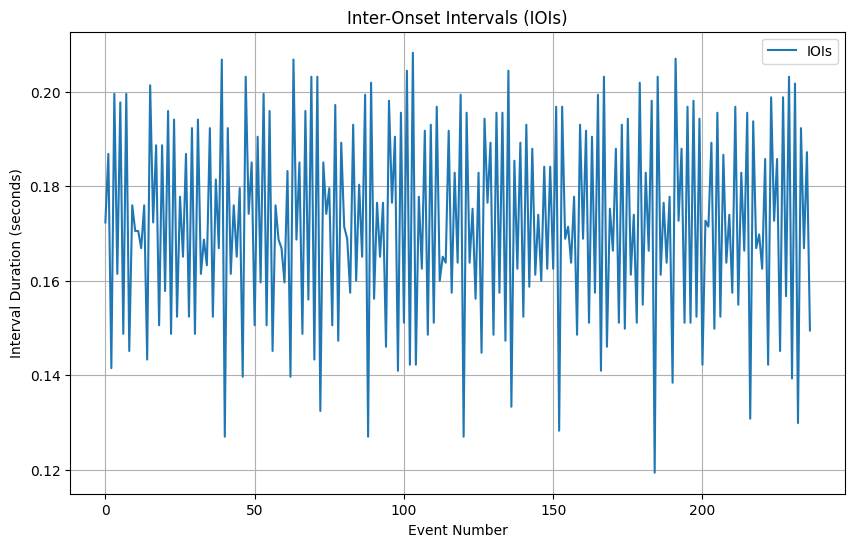

Mean IOI (Average Interval Duration): 0.17200187529535862
Standard Deviation of IOIs: 0.020776732191512208
Coefficient of Variation of IOIs: 0.12079363760328057


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Onset times in seconds
onset_times = df['TIME'].values

# Calculate inter-onset intervals (IOIs)
iois = np.diff(onset_times)

# Plot the IOIs
plt.figure(figsize=(10, 6))
plt.plot(iois, label="IOIs")
plt.title('Inter-Onset Intervals (IOIs)')
plt.xlabel('Event Number')
plt.ylabel('Interval Duration (seconds)')
plt.grid(True)
plt.legend()
plt.show()

# Calculate standard deviation and coefficient of variation
mean_ioi = np.mean(iois)
std_ioi = np.std(iois)
cv_ioi = std_ioi / mean_ioi  # Coefficient of variation

# Print out results with descriptions
print("Mean IOI (Average Interval Duration):", mean_ioi)
print("Standard Deviation of IOIs:", std_ioi)
print("Coefficient of Variation of IOIs:", cv_ioi)


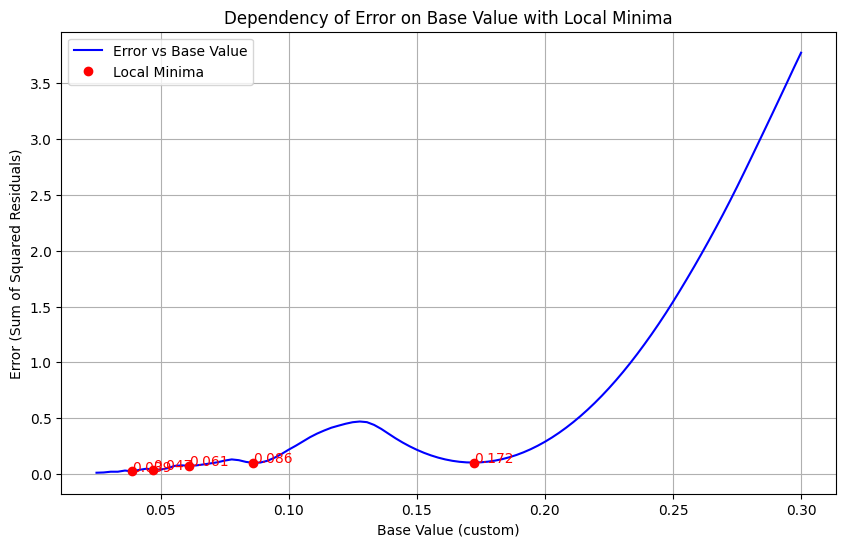

Local minima (base values) and corresponding errors:
Base Value: 0.03889, Error: 0.02310
Base Value: 0.04722, Error: 0.03911
Base Value: 0.06111, Error: 0.07330
Base Value: 0.08611, Error: 0.09935
Base Value: 0.17222, Error: 0.10232


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Example data (replace with actual data)
data = iois

# Define a range of base values to explore
base_values = np.linspace(0.025, 0.3, 100)  # Adjust range if needed

# Initialize an empty list to store the errors
errors = []

# Loop through different base values and compute the error for each
for base_value_custom in base_values:
    # Calculate multipliers and reconstructed data
    multipliers = np.round(data / base_value_custom)
    reconstructed_data = base_value_custom * multipliers

    # Calculate the residuals and error (sum of squared residuals)
    residuals = data - reconstructed_data
    error = np.sum(residuals**2)

    # Append the error to the list
    errors.append(error)

# Convert errors to a numpy array for further processing
errors = np.array(errors)

# Find local minima (by finding peaks of the negative error array)
minima_indices, _ = find_peaks(-errors)

# Plotting the dependency of the error on the base_value_custom
plt.figure(figsize=(10, 6))
plt.plot(base_values, errors, label='Error vs Base Value', color='blue')

# Mark the local minima
plt.plot(base_values[minima_indices], errors[minima_indices], 'ro', label='Local Minima')

# Annotate the local minima on the plot
for idx in minima_indices:
    plt.text(base_values[idx], errors[idx], f'{base_values[idx]:.3f}', color='red')

plt.title('Dependency of Error on Base Value with Local Minima')
plt.xlabel('Base Value (custom)')
plt.ylabel('Error (Sum of Squared Residuals)')
plt.grid(True)
plt.legend()
plt.show()

# Print out the local minima values
print("Local minima (base values) and corresponding errors:")
for idx in minima_indices:
    print(f"Base Value: {base_values[idx]:.5f}, Error: {errors[idx]:.5f}")


Error (sum of squared residuals): 0.10231768240986892


,Original IOI,Multiplier,Reconstructed IOI,Residual
0,0.172336,1.0,0.17222,0.000116
1,0.186848,1.0,0.17222,0.014628
2,0.141497,1.0,0.17222,-0.030723
3,0.199546,1.0,0.17222,0.027326
4,0.161451,1.0,0.17222,-0.010769
...,...,...,...,...
232,0.129887,1.0,0.17222,-0.042333
233,0.192290,1.0,0.17222,0.020070
234,0.166893,1.0,0.17222,-0.005327
235,0.187211,1.0,0.17222,0.014991


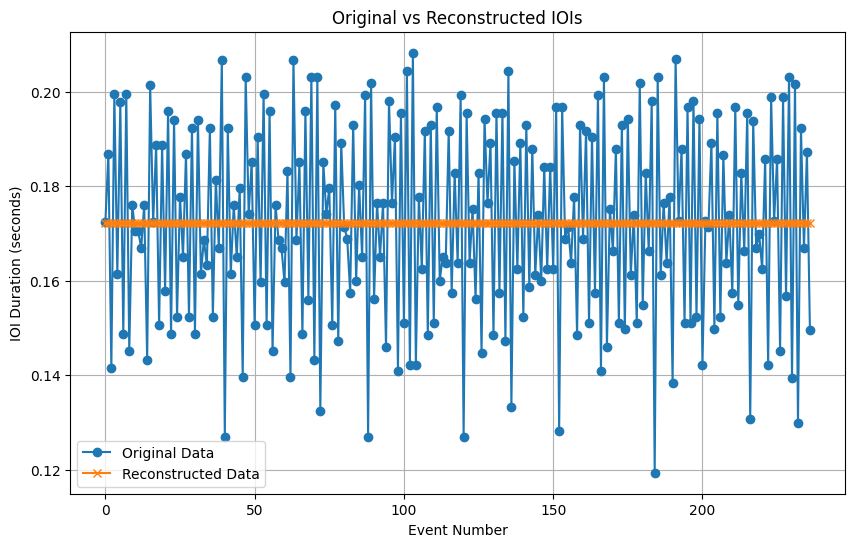

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Example data (replace with actual data)
data = iois

# Custom base value (input your desired base value here)
base_value_custom = 0.17222  # Adjust this value as needed

# Calculate multipliers and reconstructed data
multipliers = np.round(data / base_value_custom)
reconstructed_data = base_value_custom * multipliers

# Error calculation (Sum of squared residuals)
residuals = data - reconstructed_data
error = np.sum(residuals**2)

print(f"Error (sum of squared residuals): {error}")

# Create a DataFrame with Original IOI, Multiplier, Reconstructed IOI, Residual
df_results = pd.DataFrame({
    'Original IOI': data,
    'Multiplier': multipliers,
    'Reconstructed IOI': reconstructed_data,
    'Residual': residuals
})

# Display the DataFrame in Colab
display(df_results)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(data, label='Original Data', marker='o')
plt.plot(reconstructed_data, label='Reconstructed Data', marker='x')
plt.legend()
plt.title('Original vs Reconstructed IOIs')
plt.xlabel('Event Number')
plt.ylabel('IOI Duration (seconds)')
plt.grid(True)
plt.show()


mehr positive oder negatiove?

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import mido

# --- IOI Analysis and Grid Finding Functions ---
# (analyze_iois and evaluate_grid_fit functions remain the same, so they are omitted here for brevity)
# (Just make sure they are in your notebook cell)

def analyze_iois(df, onset_column):
    """Calculates and visualizes IOIs from a DataFrame."""
    if onset_column not in df.columns:
        print(f"Error: Column '{onset_column}' not found. Available columns: {list(df.columns)}")
        return np.array([]), {}
    onset_times = df[onset_column].values
    if len(onset_times) < 2: return np.array([]), {}
    iois = np.diff(onset_times)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Inter-Onset Interval (IOI) Analysis', fontsize=16)
    ax1.plot(iois, marker='.', linestyle='-', color='teal')
    ax1.set_title('IOI Sequence'); ax1.set_xlabel('Event Number'); ax1.set_ylabel('Interval Duration (s)'); ax1.grid(True, linestyle='--', alpha=0.6)
    ax2.hist(iois, bins=30, color='skyblue', edgecolor='black')
    ax2.set_title('IOI Distribution (Histogram)'); ax2.set_xlabel('Interval Duration (s)'); ax2.set_ylabel('Frequency'); ax2.grid(True, linestyle='--', alpha=0.6)
    stats = {'mean': np.mean(iois), 'std': np.std(iois)}
    stats['cv'] = stats['std'] / stats['mean'] if stats['mean'] != 0 else 0
    ax2.axvline(stats['mean'], color='red', linestyle='--', label=f"Mean: {stats['mean']:.3f}s"); ax2.legend()
    plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()
    return iois, stats

# --- (MODIFIED) find_optimal_grid_period Function ---
def find_optimal_grid_period(iois, min_period=0.1, max_period=1.0, num_steps=1000, top_n_to_label=5):
    """
    Searches for optimal grid periods, now with cleaner plotting.

    Args:
        iois (np.ndarray): Array of Inter-Onset Intervals.
        min_period (float): The minimum period to test.
        max_period (float): The maximum period to test.
        num_steps (int): The number of steps in the search range.
        top_n_to_label (int): The number of best candidates to label on the plot.

    Returns:
        tuple: A tuple containing two numpy arrays:
            - candidate_periods (np.ndarray): Array of periods at local minima.
            - candidate_errors (np.ndarray): Array of error values at those minima.
    """
    base_values = np.linspace(min_period, max_period, num_steps)
    errors = np.array([np.sum((iois - v * np.round(iois / v))**2) for v in base_values])
    
    minima_indices, _ = find_peaks(-errors, distance=5)

    if minima_indices.size == 0:
        plt.figure(figsize=(12, 6))
        plt.plot(base_values, errors, label='Quantization Error')
        plt.title('Grid Period Finding - No Local Minima Found')
        plt.show()
        return np.array([]), np.array([])

    # --- Improved Plotting Logic ---
    candidate_periods = base_values[minima_indices]
    candidate_errors = errors[minima_indices]

    # Sort candidates by error to find the best ones
    sorted_indices = np.argsort(candidate_errors)
    best_n_indices = minima_indices[sorted_indices[:top_n_to_label]]
    
    plt.figure(figsize=(12, 7))
    # Plot the main error curve
    plt.plot(base_values, errors, label='Quantization Error', color='royalblue', zorder=1)
    
    # Plot ALL found minima as small red dots
    plt.plot(candidate_periods, candidate_errors, 'o', color='red', markersize=5, label='All Local Minima', zorder=2)

    # Highlight the single BEST minimum with a prominent star
    best_idx = minima_indices[sorted_indices[0]]
    plt.plot(base_values[best_idx], errors[best_idx], '*', color='gold', markersize=15, markeredgecolor='black', label='Best Candidate', zorder=4)

    # Add text labels for only the TOP N candidates
    for idx in best_n_indices:
        plt.text(base_values[idx] + 0.005, errors[idx], f'{base_values[idx]:.3f}s', color='black', zorder=3,
                 bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))

    plt.title('Grid Period Finding by Error Minimization')
    plt.xlabel('Candidate Grid Period (s)')
    plt.ylabel('Error (Sum of Squared Residuals)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()
    
    return candidate_periods, candidate_errors

# --- Make sure your other functions (analyze_iois, evaluate_grid_fit) are also in this cell ---

def evaluate_grid_fit(iois, base_period):
    """Evaluates and visualizes how well a given grid period fits the IOI data."""
    multipliers = np.round(iois / base_period)
    reconstructed_iois = base_period * multipliers
    residuals = iois - reconstructed_iois
    df_results = pd.DataFrame({'Original_IOI': iois, 'Multiplier': multipliers.astype(int), 'Reconstructed_IOI': reconstructed_iois, 'Residual': residuals})
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Evaluation of Grid Fit for Period = {base_period:.3f}s', fontsize=16)
    ax1.plot(df_results['Original_IOI'], 'o-', label='Original IOIs', color='teal', alpha=0.8)
    ax1.plot(df_results['Reconstructed_IOI'], 'x--', label='Reconstructed Grid', color='coral', markersize=8)
    ax1.set_title('Original vs. Reconstructed IOIs'); ax1.set_xlabel('Event Number'); ax1.set_ylabel('IOI Duration (s)'); ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.6)
    ax2.hist(df_results['Residual'], bins=20, color='lightcoral', edgecolor='black')
    ax2.axvline(0, color='black', linestyle='--', label='Perfect Grid Alignment')
    ax2.set_title('Distribution of Residuals (Timing Deviations)'); ax2.set_xlabel('Residual Duration (s)'); ax2.set_ylabel('Frequency'); ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()
    return df_results

--- Step 1: Initial IOI Analysis ---


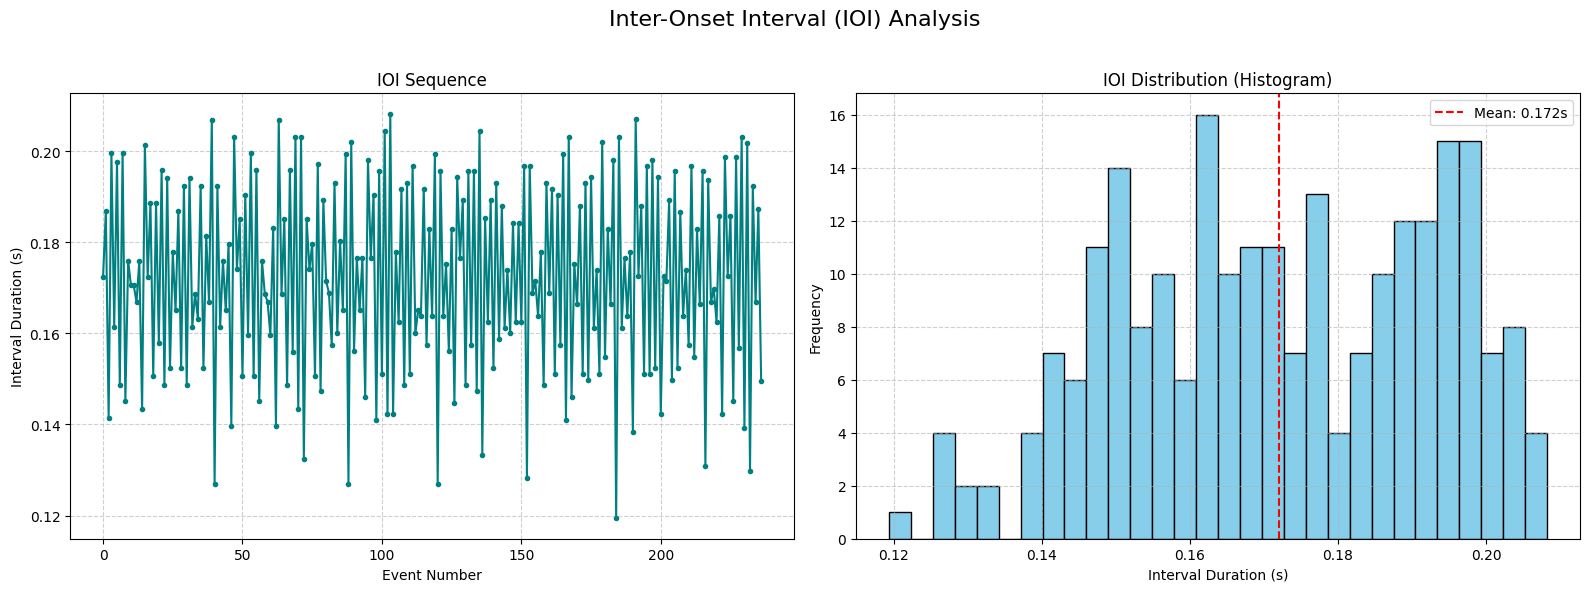


--- Step 2: Searching for Optimal Grid Period (Range: 0.1s - 0.4s) ---


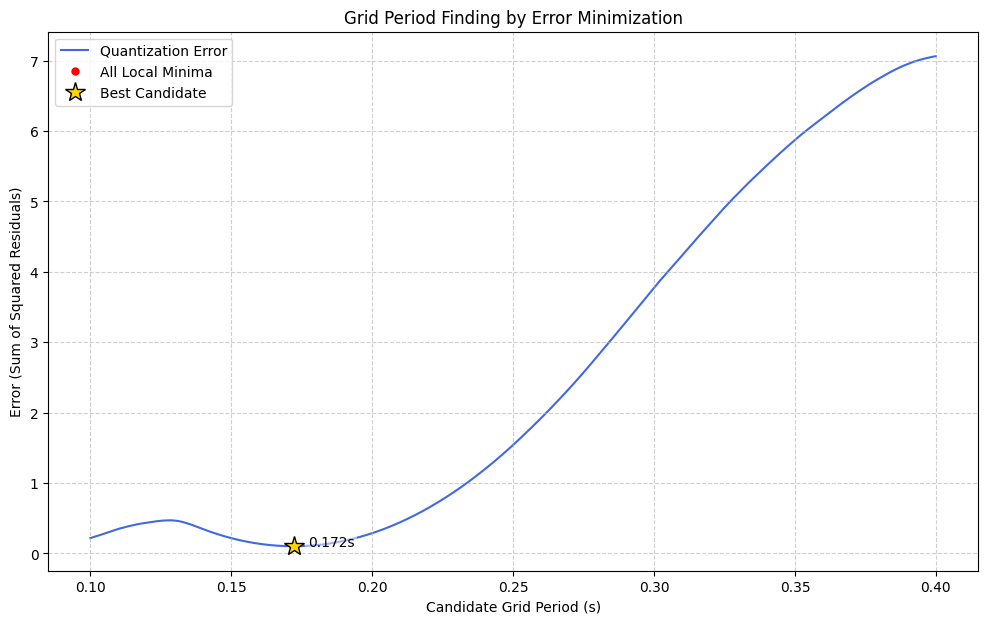


Top 1 potential grid period(s) (sorted by error):
  - Period: 0.1721 s,  Error (Loss): 0.1023  <-- Best
---------------------------------------------

--- Step 3: Evaluating the Chosen Candidate Grid ---
Automatically evaluating best-fit period: 0.1721 s


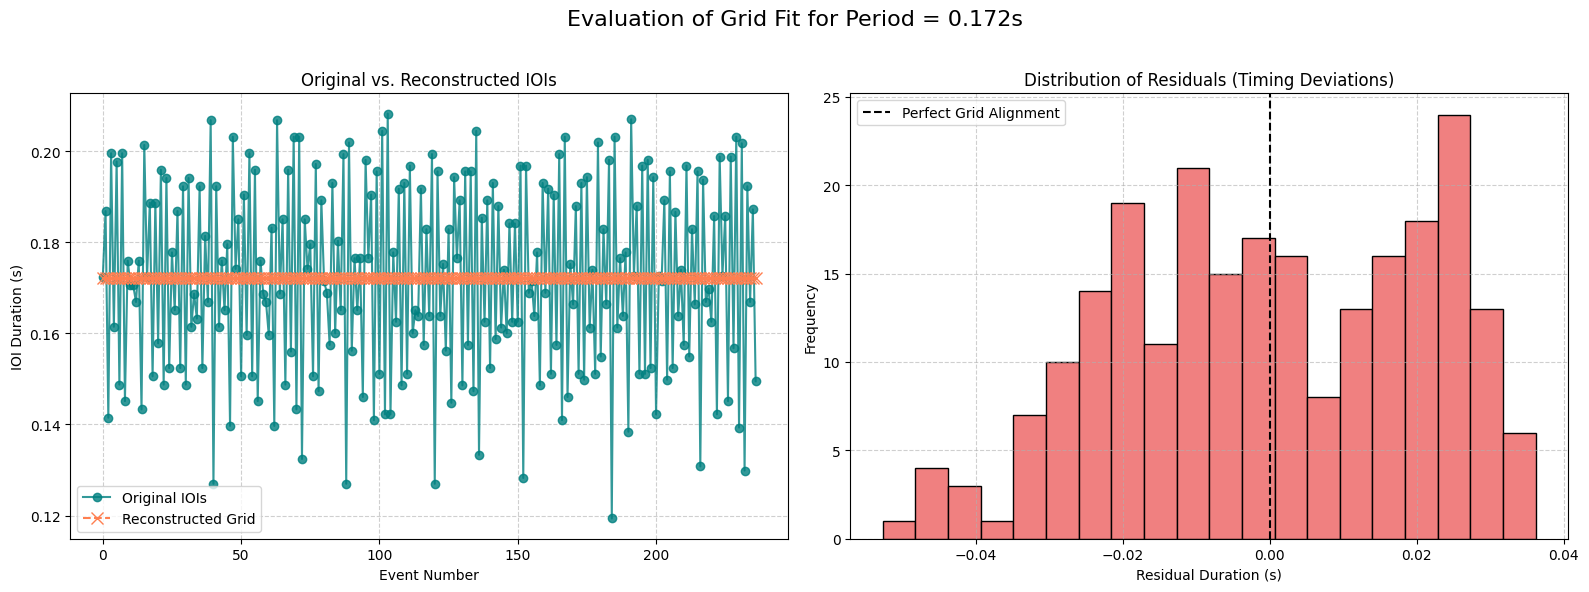


Analysis Results Table (first 5 rows):


,Original_IOI,Multiplier,Reconstructed_IOI,Residual
0,0.172336,1,0.172072,0.000264
1,0.186848,1,0.172072,0.014776
2,0.141497,1,0.172072,-0.030575
3,0.199546,1,0.172072,0.027474
4,0.161451,1,0.172072,-0.010621


In [19]:
# ===================================================================
#                          CONFIGURATION
# ===================================================================

# --- Data Configuration ---
ONSET_COLUMN_NAME = 'TIME'

# --- Grid Search Configuration ---
MIN_GRID_PERIOD_S = 0.1
MAX_GRID_PERIOD_S = 0.4
TOP_N_CANDIDATES = 5 # How many of the best candidates to show in the list and plot

# --- Evaluation Configuration ---
# To manually select a period, set this to a number (e.g., 0.247).
# To use the automatic best-fit, set this to None.
MANUAL_GRID_PERIOD_S = None # <-- SET A VALUE HERE TO OVERRIDE

# --- Results Display Configuration ---
SHOW_FULL_RESULTS_DF = False

# ===================================================================
#                         ANALYSIS WORKFLOW
# ===================================================================

if 'df' in locals() and isinstance(df, pd.DataFrame):
    
    # --- Step 1: Perform Initial IOI Analysis ---
    print("--- Step 1: Initial IOI Analysis ---")
    iois, ioi_stats = analyze_iois(df, onset_column=ONSET_COLUMN_NAME)

    if iois.size > 0:
        # --- Step 2: Find Candidate Grid Periods ---
        print(f"\n--- Step 2: Searching for Optimal Grid Period (Range: {MIN_GRID_PERIOD_S}s - {MAX_GRID_PERIOD_S}s) ---")
        candidate_periods, candidate_errors = find_optimal_grid_period(
            iois, 
            min_period=MIN_GRID_PERIOD_S, 
            max_period=MAX_GRID_PERIOD_S,
            top_n_to_label=TOP_N_CANDIDATES
        )
        
        if candidate_periods.size > 0:
            # Create a sorted list of candidates
            sorted_candidates = sorted(zip(candidate_periods, candidate_errors), key=lambda item: item[1])
            
            print(f"\nTop {min(TOP_N_CANDIDATES, len(sorted_candidates))} potential grid period(s) (sorted by error):")
            for i, (period, error) in enumerate(sorted_candidates[:TOP_N_CANDIDATES]):
                marker = "  <-- Best" if i == 0 else ""
                print(f"  - Period: {period:.4f} s,  Error (Loss): {error:.4f}{marker}")
            print("-" * 45 + "\n")

            # --- Step 3: Evaluate the Chosen Candidate ---
            print("--- Step 3: Evaluating the Chosen Candidate Grid ---")
            
            # Decide whether to use manual or automatic period
            if MANUAL_GRID_PERIOD_S is not None:
                chosen_period = MANUAL_GRID_PERIOD_S
                print(f"Manually evaluating user-specified period: {chosen_period:.4f} s")
            else:
                # Automatically select the best candidate (the first in the sorted list)
                chosen_period = sorted_candidates[0][0]
                print(f"Automatically evaluating best-fit period: {chosen_period:.4f} s")
            
            results_df = evaluate_grid_fit(iois, chosen_period)
            
            # Display results table based on configuration
            if SHOW_FULL_RESULTS_DF:
                print("\nDisplaying full Analysis Results Table:")
                try: display(results_df)
                except NameError: print(results_df.to_string())
            else:
                print("\nAnalysis Results Table (first 5 rows):")
                try: display(results_df.head())
                except NameError: print(results_df.head())
        else:
            print("\nCould not find any distinct grid periods in the specified range.")
else:
    print("\nERROR: DataFrame 'df' not found. Please run the data loading cell before this.")

In [21]:
import mido
import numpy as np

# --- Pre-computation Check ---
# Ensure all required DataFrames and variables from the analysis exist.
required_vars = ['df', 'results_df', 'chosen_period', 'ONSET_COLUMN_NAME']
if not all(v in locals() for v in required_vars):
    print("Error: Please run the data loading and analysis cells first.")
    print(f"Missing one or more of: {required_vars}")
else:
    # ===================================================================
    #                  MIDI GENERATION PARAMETERS (ADJUST THESE)
    # ===================================================================

    # 1. IOI SOURCE SELECTION
    #    - 'Reconstructed_IOI': Perfectly quantized rhythm.
    #    - 'Original_IOI': Original, expressive timing.
    IOI_SOURCE_COLUMN = 'Reconstructed_IOI'

    # 2. INITIAL GAP (PRE-ROLL) MODE (NEW!)
    #    Determines the silence before the first note.
    #    - 'original': Use the exact time of the first onset from the source data.
    #    - 'quantized': Snap the first onset time to the nearest grid line.
    #    - 'none': Start the MIDI file immediately at time 0 (no gap).
    INITIAL_GAP_MODE = 'quantized'

    # 3. DURATION MODE
    #    Options: 'ioi_ratio' or 'fixed_ms'
    duration_mode = 'ioi_ratio'

    # 4. PARAMETERS FOR 'ioi_ratio' MODE
    note_duration_ratio = 0.8

    # 5. PARAMETERS FOR 'fixed_ms' MODE
    note_duration_ms = 100

    # 6. GENERAL MIDI PARAMETERS
    midi_pitch = 36
    midi_velocity = 100

    # 7. OUTPUT FILENAME BASE
    output_midi_filename_base = 'rhythm_export'
    
    # ===================================================================
    #                          MIDI CREATION LOGIC
    # ===================================================================

    # --- Validate Inputs ---
    if IOI_SOURCE_COLUMN not in results_df.columns:
        print(f"Error: Column '{IOI_SOURCE_COLUMN}' not found in results_df.")
    elif duration_mode not in ['ioi_ratio', 'fixed_ms']:
        print(f"Error: Invalid duration_mode '{duration_mode}'.")
    elif INITIAL_GAP_MODE not in ['original', 'quantized', 'none']:
        print(f"Error: Invalid INITIAL_GAP_MODE '{INITIAL_GAP_MODE}'.")
    else:
        # --- Prepare MIDI data and settings ---
        bpm = 60.0 / chosen_period
        mido_tempo = mido.bpm2tempo(bpm)
        mid = mido.MidiFile(type=0)
        track = mido.MidiTrack()
        mid.tracks.append(track)
        track.append(mido.MetaMessage('set_tempo', tempo=mido_tempo))
        
        # --- Calculate Initial Gap (Pre-roll) ---
        initial_gap_seconds = 0.0
        if INITIAL_GAP_MODE != 'none':
            # Get the timestamp of the very first onset from the original DataFrame
            first_onset_time = df[ONSET_COLUMN_NAME].iloc[0]
            if INITIAL_GAP_MODE == 'original':
                initial_gap_seconds = first_onset_time
                print(f"Using original initial gap: {initial_gap_seconds:.4f}s")
            elif INITIAL_GAP_MODE == 'quantized':
                multiplier = np.round(first_onset_time / chosen_period)
                initial_gap_seconds = multiplier * chosen_period
                print(f"Using quantized initial gap: {initial_gap_seconds:.4f}s (Original was {first_onset_time:.4f}s)")
        else:
            print("Starting MIDI at time 0 (no initial gap).")

        # --- Prepare for event generation ---
        events = []
        # The starting time is now our calculated gap
        current_time_seconds = initial_gap_seconds 
        
        iois_for_midi = results_df[IOI_SOURCE_COLUMN].values
        
        if duration_mode == 'fixed_ms':
            fixed_duration_seconds = note_duration_ms / 1000.0

        print(f"Generating MIDI using IOIs from '{IOI_SOURCE_COLUMN}' with '{duration_mode}' duration...")

        # Loop through each IOI to create note events
        for ioi in iois_for_midi:
            note_duration_seconds = (ioi * note_duration_ratio) if duration_mode == 'ioi_ratio' else fixed_duration_seconds
            
            events.append({'type': 'note_on', 'time': current_time_seconds, 'pitch': midi_pitch, 'velocity': midi_velocity})
            events.append({'type': 'note_off', 'time': current_time_seconds + note_duration_seconds, 'pitch': midi_pitch, 'velocity': 0})
            
            current_time_seconds += ioi
            
        # Sort and convert events to MIDI messages (this logic remains the same)
        events.sort(key=lambda x: x['time'])
        last_event_time = 0
        ticks_per_beat = mid.ticks_per_beat
        for event in events:
            delta_seconds = event['time'] - last_event_time
            delta_ticks = int(mido.second2tick(delta_seconds, ticks_per_beat, mido_tempo))
            track.append(mido.Message(event['type'], note=event['pitch'], velocity=event['velocity'], time=delta_ticks))
            last_event_time = event['time']

        # --- Save the MIDI file ---
        output_filename = f"{output_midi_filename_base}_{IOI_SOURCE_COLUMN}_{duration_mode}.mid"
        try:
            mid.save(output_filename)
            print("\n--- MIDI File Creation Summary ---")
            print(f"Successfully created: '{output_filename}'")
            print(f"IOI Source: '{IOI_SOURCE_COLUMN}'")
            print(f"Initial Gap (Pre-roll): {initial_gap_seconds:.4f}s ({INITIAL_GAP_MODE} mode)")
            print(f"Tempo: {bpm:.2f} BPM")
            if duration_mode == 'ioi_ratio':
                print(f"Duration: {note_duration_ratio * 100}% of each IOI")
            else:
                print(f"Duration: {note_duration_ms} ms (fixed)")
            print("---------------------------------")
        except Exception as e:
            print(f"An error occurred while saving the MIDI file: {e}")

Error: Please run the data loading and analysis cells first.
Missing one or more of: ['df', 'results_df', 'chosen_period', 'ONSET_COLUMN_NAME']
